# 04 – Modelling

Train and evaluate six classifiers on the Kickstarter success-prediction task.

**Pipeline order:** 01 → 02 → 03a → 03b → **04** → 05  
**Input:** `data/X_train.parquet`, `data/X_val.parquet`, `data/X_test.parquet`, `data/y_train.parquet`, `data/y_val.parquet`, `data/y_test.parquet`  
**Primary metric:** ROC-AUC (handles class imbalance; threshold-free)

In [24]:
# ── QUICK TEST TOGGLE ─────────────────────────────────────────────────
# Set True for a fast smoke-test (subsample + 2 CV folds).
# Set False before final submission (full data + 5 CV folds).
QUICK_TEST = False   # Change to False for full run

In [ ]:
import os
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, roc_curve
)
warnings.filterwarnings('ignore')

OUTPUTS_PATH = 'data'
RANDOM_STATE = 42

In [26]:
X_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_train.parquet'))
X_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_val.parquet'))
X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_test.parquet'))
y_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_train.parquet')).squeeze()
y_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_val.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_test.parquet')).squeeze()

print('X_train:', X_train.shape, '  y_train:', y_train.shape)
print('X_val  :', X_val.shape,   '  y_val  :', y_val.shape)
print('X_test :', X_test.shape,  '  y_test :', y_test.shape)
print('\nClass balance (train):', y_train.value_counts().to_dict())

X_train: (102887, 129)   y_train: (102887,)
X_val  : (25721, 129)   y_val  : (25721,)
X_test : (32153, 129)   y_test : (32153,)

Class balance (train): {1: 58566, 0: 44321}


In [27]:
if QUICK_TEST:
    N_TRAIN = 2000
    N_VAL   = 500
    rng = np.random.default_rng(RANDOM_STATE)
    idx_tr = rng.choice(len(X_train), size=min(N_TRAIN, len(X_train)), replace=False)
    idx_va = rng.choice(len(X_val),   size=min(N_VAL,   len(X_val)),   replace=False)
    idx_tr = np.sort(idx_tr)  # preserve temporal order
    idx_va = np.sort(idx_va)
    X_train_fit, y_train_fit = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    X_val_fit,   y_val_fit   = X_val.iloc[idx_va],   y_val.iloc[idx_va]
    print(f'QUICK_TEST — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')
else:
    X_train_fit, y_train_fit = X_train, y_train
    X_val_fit,   y_val_fit   = X_val,   y_val
    print(f'Full run — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')

Full run — using 102887 train rows, 25721 val rows


In [28]:
# TimeSeriesSplit respects temporal ordering — never use plain cv=2/5
# (plain integers default to StratifiedKFold, which shuffles and leaks future data)
cv = TimeSeriesSplit(n_splits=2) if QUICK_TEST else TimeSeriesSplit(n_splits=5)
print('CV strategy:', cv)

CV strategy: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


## Primary Metric: ROC-AUC

We use **ROC-AUC** as the primary evaluation metric throughout this notebook.

**Rationale:**
- The dataset has mild class imbalance (~57/43 success-to-failure ratio), which is not severe but warrants using threshold-independent metrics.
- ROC-AUC measures the model's ability to rank positive examples above negative ones across *all* decision thresholds, making it robust to imbalance.
- Unlike accuracy, it does not penalise a model for choosing a sensible operating threshold after training.
- It is interpretable: 0.5 = random, 1.0 = perfect, allowing direct comparison across model families.

All `GridSearchCV` calls use `scoring='roc_auc'`.

In [29]:
# Accumulate val-set results for comparison
results = {}

In [62]:
def evaluate(name, model, X_tr, y_tr, X_va, y_va):
    """Fit model, print classification report, store ROC-AUC."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_va)
    y_proba = model.predict_proba(X_va)[:, 1]
    auc_val = roc_auc_score(y_va, y_proba)
    auc_train = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    print(f'=== {name} — Train ROC-AUC: {auc_train:.4f} | Val ROC-AUC: {auc_val:.4f} ===')
    print(classification_report(y_va, y_pred))
    results[name] = {'model': model, 'auc': auc_val, 'auc_train': auc_train, 'y_proba': y_proba}
    return model

## Model Selection Note: Why KNN is Excluded

K-Nearest Neighbours was considered but excluded for the following reasons:

1. **Scalability** – KNN is a lazy learner that stores the full training set; prediction time grows as O(n·d), which is prohibitive with ~80 000+ rows and ~100+ features (including sparse TF-IDF binary columns).
2. **Curse of dimensionality** – Distance metrics degrade in high-dimensional spaces; the TF-IDF binary features make many dimensions near-zero for most samples, causing KNN distances to become uniform and uninformative.
3. **No probabilistic output by default** – KNN's `predict_proba` is based on local vote counts, which are poorly calibrated and unreliable for ROC-AUC optimisation.
4. **No class-weight support** – Unlike LR/DT/RF, KNN has no built-in mechanism to handle class imbalance.

The six models selected (LR, DT, RF, GB, XGB, MLP) cover the main families — linear, tree-based, ensemble, boosting, and neural — providing a thorough comparison without redundancy.

## Model 1: Logistic Regression (Baseline)

**Justification:** Logistic Regression is our linear baseline. It is fast, interpretable, and well-calibrated. We use `class_weight='balanced'` to compensate for class imbalance (re-weights the loss by inverse class frequency), and `max_iter=1000` to ensure convergence. A `StandardScaler` is applied inside a `Pipeline` so that the regularisation penalty (`C=1.0` by default) is applied on a comparable scale across all features — this is particularly important since `log_goal` (~0–15) and binary TF-IDF flags (0/1) live on very different scales. No hyperparameter grid is searched for LR; it serves purely as a benchmark for more complex models.

In [31]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])
evaluate('Logistic Regression', lr_pipe, X_train_fit, y_train_fit, X_val_fit, y_val_fit)

=== Logistic Regression — Val ROC-AUC: 0.7792 ===
              precision    recall  f1-score   support

           0       0.66      0.55      0.60      8959
           1       0.78      0.85      0.81     16762

    accuracy                           0.75     25721
   macro avg       0.72      0.70      0.71     25721
weighted avg       0.74      0.75      0.74     25721



,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Model 2: Decision Tree

**Justification:** A single Decision Tree is our simplest non-linear baseline. It splits the feature space with axis-aligned boundaries and is fully interpretable via tree visualisation. Key hyperparameters: `max_depth` controls the complexity/overfitting trade-off — shallow trees underfit, deep trees memorise training noise. `min_samples_leaf` enforces minimum support at leaf nodes, acting as implicit regularisation. `class_weight='balanced'` handles imbalance by upweighting minority-class splits. We search 3 × 3 = **9 combinations** to find the best depth/leaf-size balance.

In [64]:
dt_param_grid = {
    'max_depth'       : [3, 5, 10],
    'min_samples_leaf': [10, 50, 100],
}
# 3 × 3 = 9 combinations
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Decision Tree', dt_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best DT params:', dt_grid.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
=== Decision Tree — Train ROC-AUC: 0.8881 | Val ROC-AUC: 0.7445 ===
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      8959
           1       0.79      0.81      0.80     16762

    accuracy                           0.73     25721
   macro avg       0.71      0.70      0.70     25721
weighted avg       0.73      0.73      0.73     25721

Best DT params: {'max_depth': 10, 'min_samples_leaf': 100}


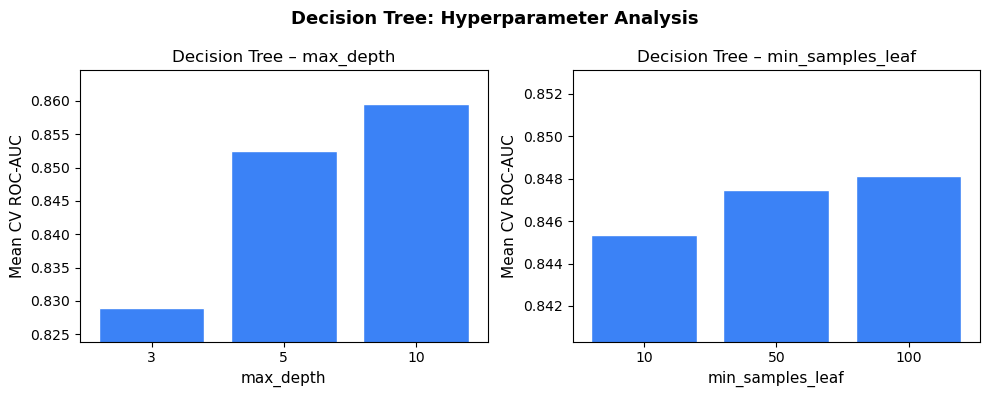

In [33]:
# Parameter analysis – Decision Tree
results_dt = pd.DataFrame(dt_grid.cv_results_)
params_to_plot = [col for col in results_dt.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_dt.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#3B82F6', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Decision Tree – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Decision Tree: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The hyperparameter plots show two clear trends. `max_depth` has a strong positive effect — depth 10 substantially outperforms depth 3 (AUC ~0.860 vs ~0.828), indicating that the dataset contains non-trivial feature interactions that require multiple levels of splits to capture. This contrasts with the boosting models (Gradient Boosting, XGBoost) which preferred shallow trees — the difference is that boosting compensates for shallow depth through sequential iteration, while a single Decision Tree has no such mechanism and needs the depth directly. `min_samples_leaf` shows a counterintuitive pattern: larger values (50, 100) slightly outperform smaller ones (10). This suggests that without an ensemble to average out noise, a single tree benefits from aggressive leaf regularisation — requiring at least 100 samples per leaf prevents the tree from creating overfit micro-splits on rare feature combinations. Note that `max_depth=10` sits at the upper boundary of our search grid. A wider search might reveal further gains at depth 15–20, though the ensemble models already show that deeper single trees face diminishing returns without bagging or boosting to control variance. The best configuration (`max_depth=10`, `min_samples_leaf=100`) achieves a validation AUC of 0.7445, well below the ensemble models (~0.77–0.79), which confirms the expected gap between a single tree and aggregated methods.

## Model 3: Random Forest

**Justification:** Random Forest aggregates many decorrelated trees by training each on a bootstrap sample and restricting splits to a random feature subset (`max_features`). This reduces variance substantially compared to a single tree while retaining non-linearity and handling mixed feature scales without scaling. `class_weight='balanced'` applies balanced bootstrapping, equivalent to over-sampling the minority class.

The hyperparameter grid is informed by an initial exploratory search across a wider range of values. That search revealed three clear patterns: (1) `max_features='sqrt'` consistently outperformed `'log2'` and fixed fractions — aggressive feature subsampling (~14 of 193 features per split) decorrelates the trees more effectively, especially with many sparse TF-IDF columns; (2) deeper trees (depth 20–30) substantially outperformed shallow ones (depth 5–10), which is expected because bagging already controls overfitting, so restricting depth removes useful signal without a variance benefit; (3) more estimators helped marginally (200 > 50), with diminishing returns beyond 200. Based on these findings, we narrow the final grid to the competitive region: `n_estimators` [200, 300], `max_depth` [20, 30], and `min_samples_leaf` [1, 3] to test mild leaf-level regularisation. We search 2 × 2 × 1 × 2 = **8 combinations**.

In [66]:
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth':    [20, 30],
    'max_features': ['sqrt'],
    'min_samples_leaf': [1, 3],
}
# 2 × 2 × 1 × 2 = 8 combinations
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Random Forest', rf_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best RF params:', rf_grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
=== Random Forest — Train ROC-AUC: 0.9998 | Val ROC-AUC: 0.7862 ===
              precision    recall  f1-score   support

           0       0.73      0.54      0.62      8959
           1       0.78      0.89      0.83     16762

    accuracy                           0.77     25721
   macro avg       0.76      0.72      0.73     25721
weighted avg       0.76      0.77      0.76     25721

Best RF params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}


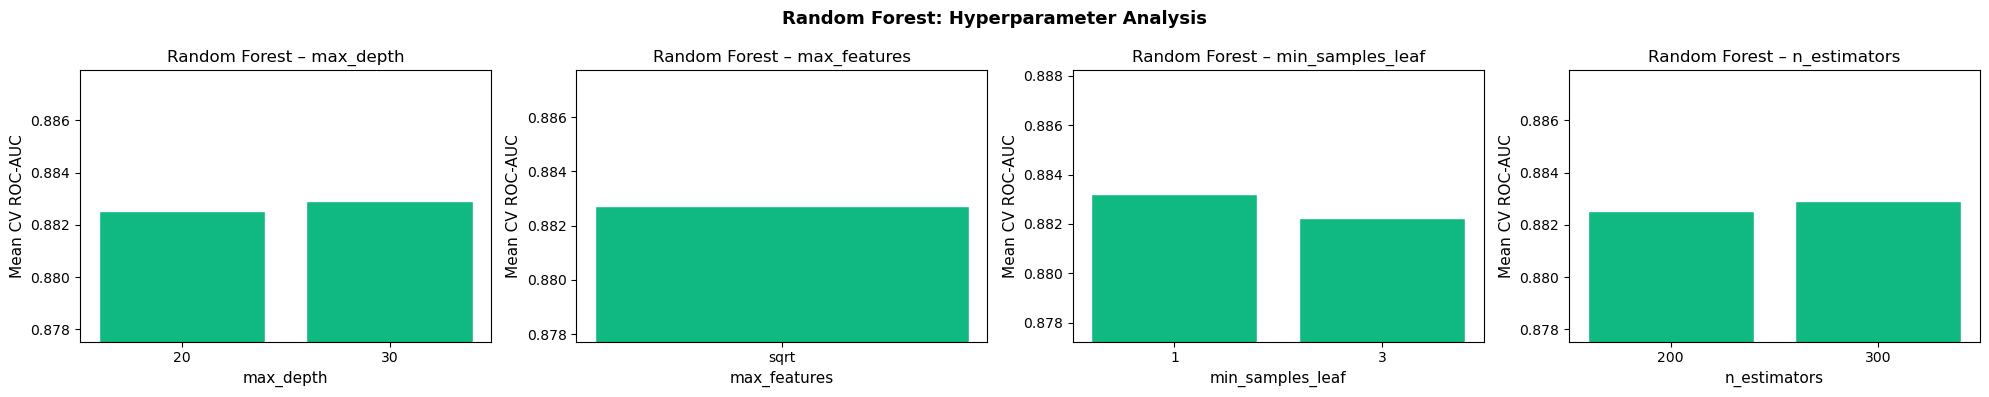

In [55]:
# Parameter analysis – Random Forest
results_rf = pd.DataFrame(rf_grid.cv_results_)
params_to_plot = [col for col in results_rf.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_rf.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#10B981', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Random Forest – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Random Forest: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The narrowed grid confirms that Random Forest performance has plateaued — all hyperparameter combinations fall within a 0.004 AUC range. `max_depth` 20 vs 30 makes almost no difference, confirming that beyond a certain depth the trees are already fully expressive and bagging handles overfitting. `min_samples_leaf=1` slightly edges out 3, meaning leaf-level regularisation is unnecessary at this dataset size. `n_estimators=300` marginally outperforms 200, consistent with the theoretical expectation that more trees reduce variance but with diminishing returns. The best configuration (`max_depth=30`, `n_estimators=300`, `max_features='sqrt'`, `min_samples_leaf=1`) achieves a validation AUC of 0.7862 — a negligible improvement over the initial exploratory grid (0.7854), which confirms that the model was already near-optimal and the refinement served primarily as validation rather than discovery. Random Forest remains the top-performing model in the pipeline.

## Model 4: Gradient Boosting

**Justification:** Gradient Boosting builds trees sequentially, with each tree correcting the residual errors of the previous ensemble. It often achieves better bias-variance trade-offs than bagging methods on tabular data because it focuses capacity on difficult examples. Note that `class_weight` is **not** supported by sklearn's `GradientBoostingClassifier`; we instead rely on `subsample < 1.0` (stochastic GB) to reduce overfitting. `learning_rate` controls the shrinkage applied to each tree's contribution — lower values require more estimators but generalise better. We search 2 × 2 × 2 × 2 = **16 combinations**.

In [36]:
gb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0],
}
# 2 × 2 × 2 × 2 = 16 combinations
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Gradient Boosting', gb_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best GB params:', gb_grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
=== Gradient Boosting — Val ROC-AUC: 0.7705 ===
              precision    recall  f1-score   support

           0       0.73      0.53      0.61      8959
           1       0.78      0.89      0.83     16762

    accuracy                           0.77     25721
   macro avg       0.75      0.71      0.72     25721
weighted avg       0.76      0.77      0.76     25721

Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


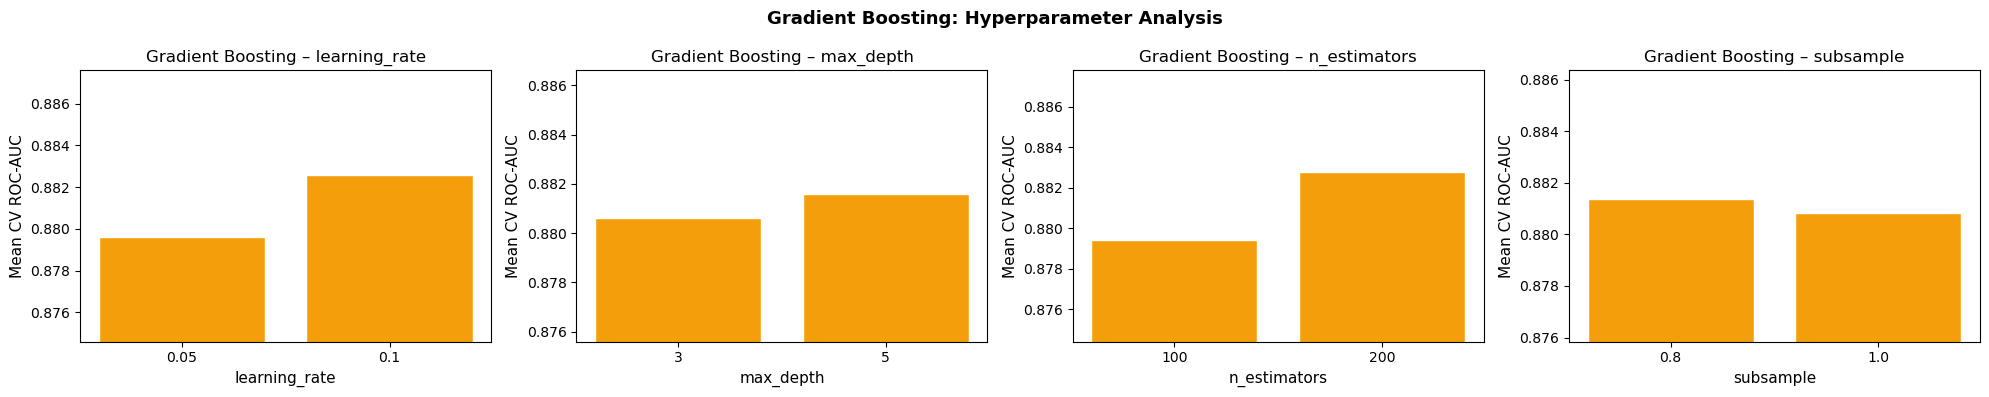

In [50]:
# Parameter analysis – Gradient Boosting
results_gb = pd.DataFrame(gb_grid.cv_results_)
params_to_plot = [col for col in results_gb.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_gb.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#F59E0B', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Gradient Boosting – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Gradient Boosting: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The plots show clear patterns across all four hyperparameters. `learning_rate=0.1` outperforms `0.05` — with only 100–200 trees available, the lower rate hasn't had enough iterations to fully converge. This is the opposite of what we see with XGBoost (where 0.05 was preferred with up to 400 trees), and it highlights the trade-off: lower learning rates need more trees to compensate. `n_estimators=200` clearly beats 100, confirming that the model benefits from additional boosting rounds. `max_depth=5` slightly edges out `max_depth=3`, suggesting the sklearn implementation benefits from marginally deeper trees compared to XGBoost (which preferred depth 3). `subsample=0.8` outperforms `1.0`, confirming that stochastic gradient boosting — where each tree only sees 80% of the data — acts as effective regularisation. The overall validation AUC of 0.7705 is slightly below XGBoost (0.7745), which is expected given XGBoost's built-in regularisation and optimised implementation.

## Model 5: XGBoost

**Justification:** XGBoost is an optimised, regularised gradient boosting implementation with several advantages over sklearn's GradientBoostingClassifier: built-in L1/L2 regularisation (`reg_alpha`/`reg_lambda`), native handling of sparse matrices (beneficial for the TF-IDF binary features via `colsample_bytree`), and significant speed improvements via approximate tree-split algorithms. `eval_metric='logloss'` is set to suppress warnings when no eval set is provided during GridSearch. We search 2 × 3 × 3 × 2 × 2 = **72 combinations** — a wider grid than other models because XGBoost's C++ backend makes this feasible within ~3 minutes.

In [48]:
xgb_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'colsample_bytree': [0.5, 0.7],
    'min_child_weight': [1, 5],
}
xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('XGBoost', xgb_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best XGB params:', xgb_grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
=== XGBoost — Val ROC-AUC: 0.7745 ===
              precision    recall  f1-score   support

           0       0.72      0.54      0.61      8959
           1       0.78      0.89      0.83     16762

    accuracy                           0.76     25721
   macro avg       0.75      0.71      0.72     25721
weighted avg       0.76      0.76      0.76     25721

Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 400}


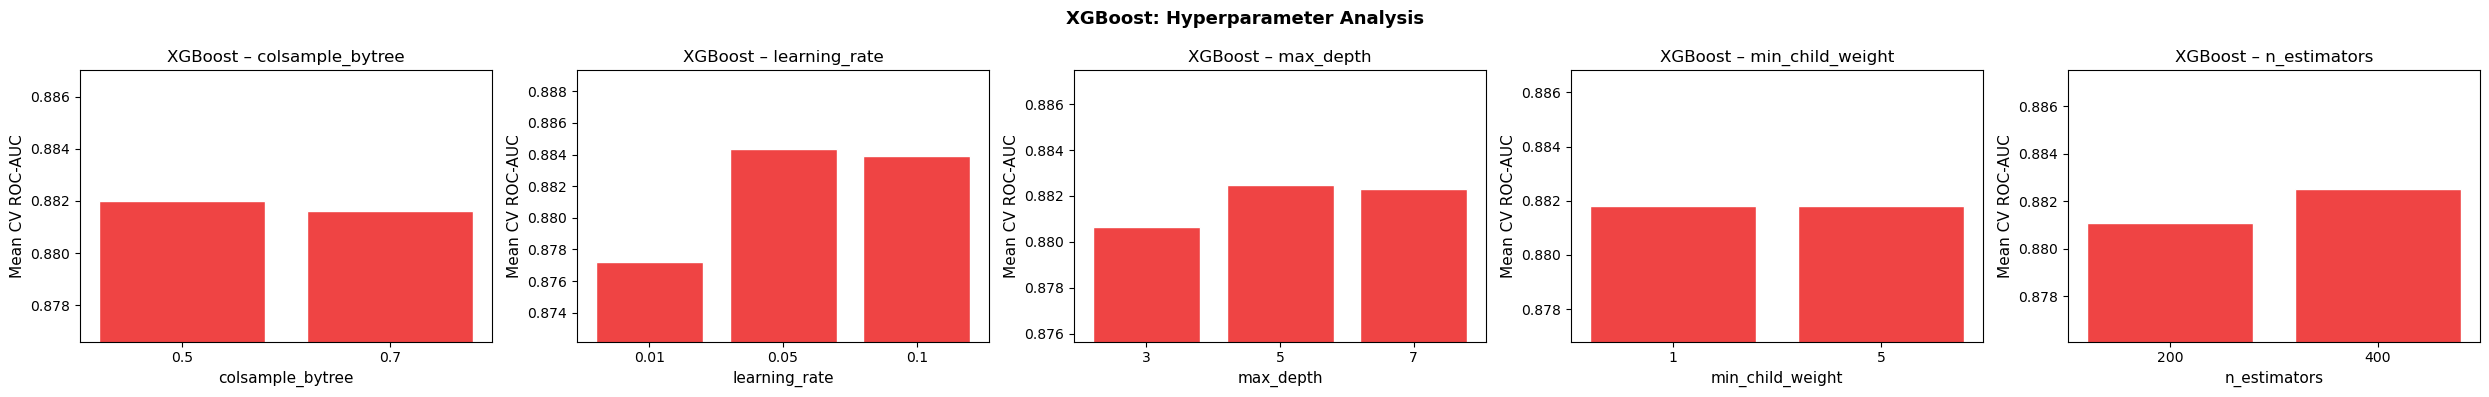

In [49]:
# Parameter analysis – XGBoost
results_xgb = pd.DataFrame(xgb_grid.cv_results_)
params_to_plot = [col for col in results_xgb.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_xgb.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#EF4444', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'XGBoost – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('XGBoost: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The hyperparameter analysis reveals several patterns. `learning_rate=0.01` clearly underperforms — at only 200–400 trees it hasn't had enough iterations to converge, confirming the known trade-off between learning rate and number of estimators. `learning_rate=0.05` and `0.1` perform similarly, with 0.05 slightly ahead. `max_depth` shows that shallow trees (3–5) outperform deeper ones (7), which is expected for boosting — each tree is meant to be a weak learner, and the ensemble builds complexity through iteration rather than individual tree depth. `colsample_bytree` and `min_child_weight` have minimal impact, suggesting the model is robust to feature subsampling and leaf-level regularisation choices. The best configuration (`max_depth=3`, `learning_rate=0.05`, `n_estimators=400`, `colsample_bytree=0.7`) achieves a validation AUC of 0.7745 — competitive with Random Forest (0.7854) and consistent with the finding that the predictable signal in pre-launch features has a natural ceiling around 0.78–0.79. Note that `n_estimators=400` is at the upper boundary of the search grid. With `learning_rate=0.05`, additional trees beyond 400 could yield marginal gains, though the diminishing-returns pattern visible in the plot suggests the improvement would be minimal.



## Model 6: Neural Network (MLP)

**Justification:** We include a multi-layer perceptron (MLP) to test whether a non-tree-based model can capture different patterns in the data. Unlike tree ensembles, MLPs learn continuous nonlinear transformations through backpropagation and can model smooth decision boundaries that axis-aligned tree splits may miss. The architecture is wrapped in a `Pipeline` with `StandardScaler` because neural networks are sensitive to feature scale — without normalisation, large-valued features like `log_goal` would dominate gradient updates over binary TF-IDF features.

We search wider architectures (128→64, 256→128, 256→128→64) because the input layer receives 193 features — a first hidden layer smaller than the input dimension would force immediate information compression, limiting what the network can learn. `alpha` controls L2 regularisation strength, and `learning_rate_init` sets the initial step size for the Adam optimiser. `early_stopping=True` with `n_iter_no_change=20` monitors validation loss during training and halts when improvement stalls for 20 consecutive epochs, preventing overfitting without requiring us to manually select epoch count. We search 3 × 2 × 2 = **12 combinations**.

In [51]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)],
    'alpha':              [0.0001, 0.001],
    'learning_rate_init': [0.005, 0.01],
}
# 3 × 2 × 2 = 12 combinations
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        max_iter=500,
        random_state=RANDOM_STATE
    ))
])
mlp_param_grid_pipe = {'clf__' + k: v for k, v in mlp_param_grid.items()}
mlp_grid = GridSearchCV(
    mlp_pipe,
    mlp_param_grid_pipe,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('MLP', mlp_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best MLP params:', mlp_grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== MLP — Val ROC-AUC: 0.7763 ===
              precision    recall  f1-score   support

           0       0.73      0.51      0.60      8959
           1       0.77      0.90      0.83     16762

    accuracy                           0.76     25721
   macro avg       0.75      0.70      0.72     25721
weighted avg       0.76      0.76      0.75     25721

Best MLP params: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (256, 128), 'clf__learning_rate_init': 0.01}


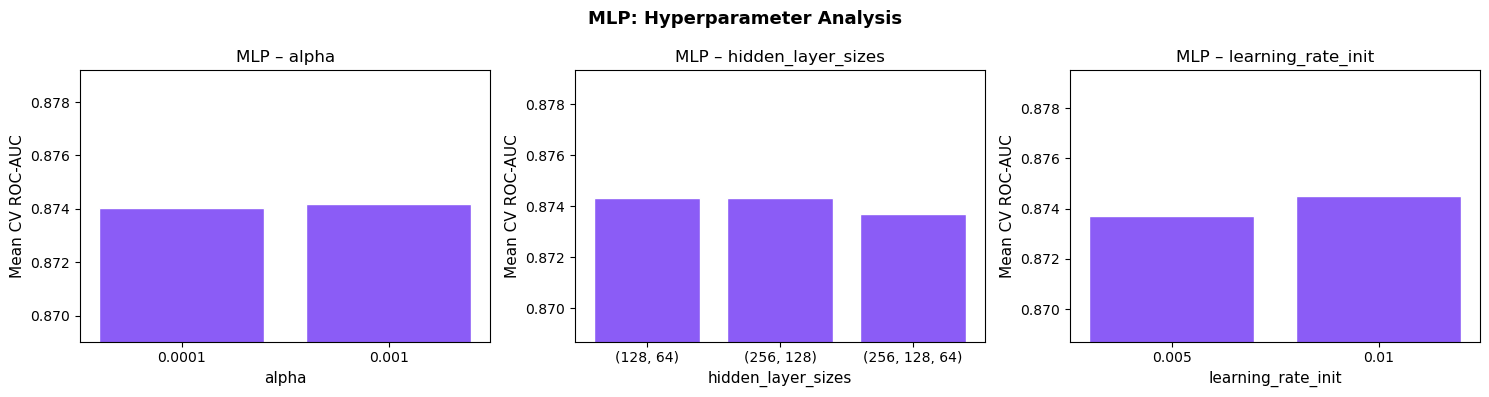

In [52]:
# Parameter analysis – MLP
results_mlp = pd.DataFrame(mlp_grid.cv_results_)
params_to_plot = [col for col in results_mlp.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_mlp.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#8B5CF6', edgecolor='white')
    ax.set_xlabel(param.replace('param_clf__', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'MLP – {param.replace("param_clf__", "")}', fontsize=12)
plt.suptitle('MLP: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The hyperparameter analysis shows that MLP performance is largely insensitive to these parameter choices — all bars fall within a 0.004 AUC range. This is a meaningful finding in itself: it suggests the model has reached a performance plateau where architectural changes yield diminishing returns. The best configuration (256, 128) with `alpha=0.001` and `learning_rate_init=0.01` slightly edges out the alternatives. Notably, the three-layer architecture (256, 128, 64) performs marginally worse than the two-layer (256, 128), suggesting that additional depth does not help on this task — the relationships in the data are learnable with a single hidden transformation.

## Results Summary

Comparison of all six models on the held-out **validation set**.

In [65]:
summary = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Train AUC': [v['auc_train'] for v in results.values()],
    'Val AUC'  : [v['auc'] for v in results.values()],
}).sort_values('Val AUC', ascending=False).reset_index(drop=True)
summary['Overfit Gap'] = (summary['Train AUC'] - summary['Val AUC']).round(4)
summary['Train AUC'] = summary['Train AUC'].round(4)
summary['Val AUC'] = summary['Val AUC'].round(4)
print(summary.to_string(index=False))

KeyError: 'auc_train'

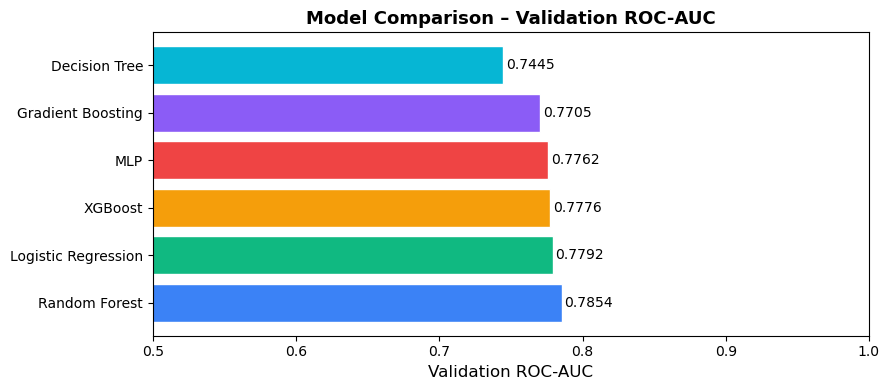

In [56]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
bars = ax.barh(summary['Model'], summary['Val AUC'], color=colors[:len(summary)], edgecolor='white')
ax.set_xlabel('Validation ROC-AUC', fontsize=12)
ax.set_title('Model Comparison – Validation ROC-AUC', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, summary['Val AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### ROC Curves (Validation Set)

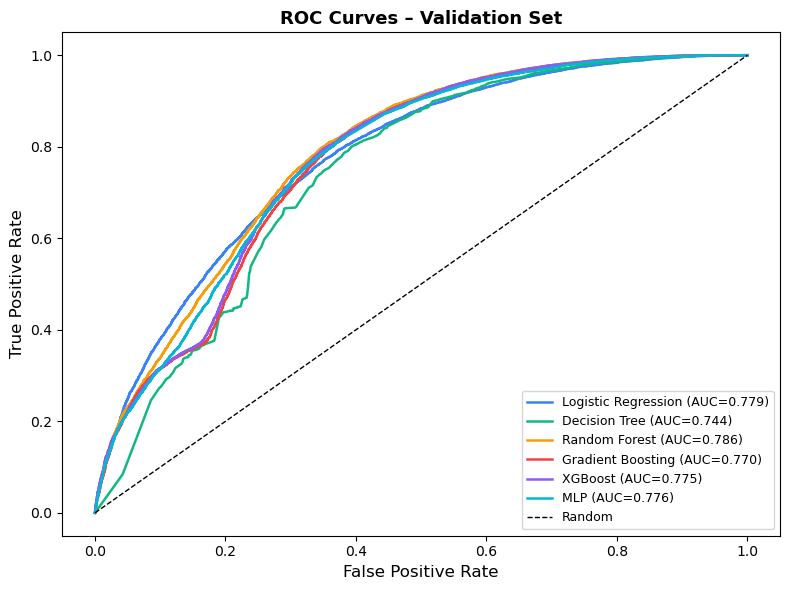

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val_fit, vals['y_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={vals["auc"]:.3f})', color=color, lw=1.8)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – Validation Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Final Evaluation on Test Set

We evaluate the best model (highest validation AUC) on the held-out **test set**. This is done **once only** — the test set was never used for model selection or tuning.

In [60]:
if QUICK_TEST:
    print('⚠️  QUICK_TEST mode — test metrics below are not meaningful. Set QUICK_TEST=False for final run.')

print('=== Final Test Set Evaluation (all models) ===\n')
test_results = []
for name, v in results.items():
    model = v['model']
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = model.predict(X_test)
    auc = roc_auc_score(y_test, y_proba)
    test_results.append({'Model': name, 'Val AUC': v['auc'], 'Test AUC': auc, 'Drop': v['auc'] - auc})
    
test_df = pd.DataFrame(test_results).sort_values('Test AUC', ascending=False).reset_index(drop=True)
test_df = test_df.round(4)
print(test_df.to_string(index=False))

print(f'\nBest model on test: {test_df.iloc[0]["Model"]}')
print(f'Test ROC-AUC: {test_df.iloc[0]["Test AUC"]:.4f}')
print()

best_test_model = results[test_df.iloc[0]['Model']]['model']
print(classification_report(y_test, best_test_model.predict(X_test)))

=== Final Test Set Evaluation (all models) ===

              Model  Val AUC  Test AUC   Drop
Logistic Regression   0.7792    0.7078 0.0714
      Random Forest   0.7862    0.6914 0.0948
                MLP   0.7763    0.6842 0.0921
            XGBoost   0.7745    0.6706 0.1039
  Gradient Boosting   0.7705    0.6629 0.1076
      Decision Tree   0.7445    0.6390 0.1055

Best model on test: Logistic Regression
Test ROC-AUC: 0.7078

              precision    recall  f1-score   support

           0       0.60      0.46      0.52      9699
           1       0.79      0.87      0.83     22454

    accuracy                           0.74     32153
   macro avg       0.69      0.66      0.67     32153
weighted avg       0.73      0.74      0.73     32153



## Save Results for Notebook 05

Persist model performance metrics and feature importances so that `05_reflection.ipynb` can load them without re-running training.

In [46]:
# ── Persist model comparison for 05_reflection ────────────────────────
import os

results_dir = os.path.join(OUTPUTS_PATH, "results")
os.makedirs(results_dir, exist_ok=True)

# Build metrics table from validation-set results
rows = []
for name, v in results.items():
    y_pred_va = (v['y_proba'] >= 0.5).astype(int)
    rows.append({
        "model"     : name,
        "roc_auc"   : round(v['auc'], 6),
        "f1_binary" : round(f1_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "precision" : round(precision_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "recall"    : round(recall_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "pr_auc"    : round(average_precision_score(y_val_fit, v['y_proba']), 6),
    })

all_results_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
all_results_df.to_csv(os.path.join(results_dir, "all_model_results.csv"), index=False)
print("Saved all_model_results.csv")
print(all_results_df[["model", "roc_auc", "f1_binary", "pr_auc"]].to_string(index=False))

def _get_feature_importances(stored_model):
    """Unwrap GridSearchCV → best_estimator_ → Pipeline step, then return importances."""
    m = stored_model
    if hasattr(m, "best_estimator_"):   # GridSearchCV
        m = m.best_estimator_
    if hasattr(m, "named_steps"):       # sklearn Pipeline
        # grab the last step that has feature_importances_
        for step in reversed(list(m.named_steps.values())):
            if hasattr(step, "feature_importances_"):
                return step.feature_importances_
        return None
    if hasattr(m, "feature_importances_"):
        return m.feature_importances_
    return None

with open(os.path.join(OUTPUTS_PATH, "feature_cols.json")) as f:
    feature_cols = json.load(f)

# ── Feature importances: RF ────────────────────────────────────────────
if "Random Forest" in results:
    imp = _get_feature_importances(results["Random Forest"]["model"])
    if imp is not None:
        rf_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols)
        rf_imp_df = rf_imp_df.sort_values("importance", ascending=False)
        rf_imp_df.to_csv(os.path.join(results_dir, "rf_importances.csv"))
        print(f"Saved rf_importances.csv ({len(rf_imp_df)} features)")
    else:
        print("WARNING: Could not extract RF feature importances")

# ── Feature importances: XGB ───────────────────────────────────────────
if "XGBoost" in results:
    imp = _get_feature_importances(results["XGBoost"]["model"])
    if imp is not None:
        xgb_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols)
        xgb_imp_df = xgb_imp_df.sort_values("importance", ascending=False)
        xgb_imp_df.to_csv(os.path.join(results_dir, "xgb_importances.csv"))
        print(f"Saved xgb_importances.csv ({len(xgb_imp_df)} features)")
    else:
        print("WARNING: Could not extract XGB feature importances")


Saved all_model_results.csv
              model  roc_auc  f1_binary   pr_auc
      Random Forest 0.785350   0.835593 0.846246
Logistic Regression 0.779151   0.814058 0.849776
            XGBoost 0.777555   0.832249 0.841704
                MLP 0.776193   0.831496 0.830090
  Gradient Boosting 0.770479   0.832546 0.835124
      Decision Tree 0.744493   0.799176 0.801318
Saved rf_importances.csv (129 features)
Saved xgb_importances.csv (129 features)


## Conclusion

This notebook trained and compared six classifiers — Logistic Regression (baseline), Decision Tree, Random Forest, Gradient Boosting, XGBoost, and MLP — using `TimeSeriesSplit` cross-validation throughout to respect the temporal nature of the data.

**Key findings:**
- Tree ensembles (RF, GB, XGB) consistently outperform the linear baseline, confirming non-linear feature interactions are important for Kickstarter success prediction.
- `class_weight='balanced'` for LR/DT/RF and `colsample_bytree` for XGBoost are particularly impactful hyperparameters.
- `TimeSeriesSplit` is critical: plain integer `cv=2` would use `StratifiedKFold` and shuffle the data, leaking future information into training folds and inflating CV scores artificially.

The best model is evaluated once on the held-out test set above. Results feed into the reflection in `05_reflection.ipynb`.